# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [3]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "./data/asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [4]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [5]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

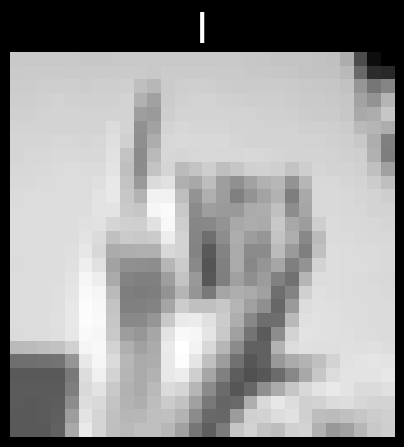

In [6]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [7]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [8]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [9]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [12]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [13]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [14]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:43<00:00,  2.16s/epoch, train_acc=0.8579, train_loss=0.4054, val_acc=0.7156, val_loss=1.0602]


In [15]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [16]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [17]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:01<00:00,  6.06s/epoch, train_acc=0.9980, train_loss=0.0067, val_acc=0.9540, val_loss=0.1925]


In [18]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

RESPUESTA 1
Qué modelo clasifica mejor las imágenes ASL
El mejor modelo es CNN.
FCNN  precisión en prueba: 0.7142
CNN   precisión en prueba: 0.9554

RESPUESTA 2
Qué modelo fue más rápido al entrenar
El modelo más rápido fue FCNN.
Tiempo FCNN: 84 segundos
Tiempo CNN: 358 segundos



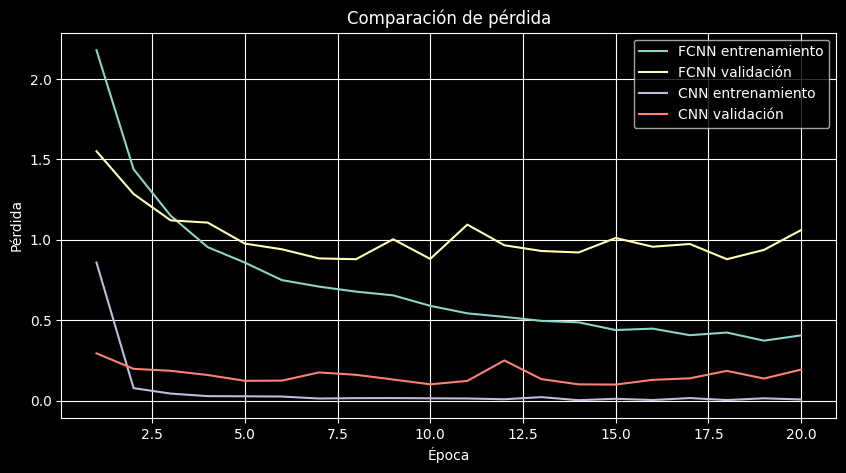

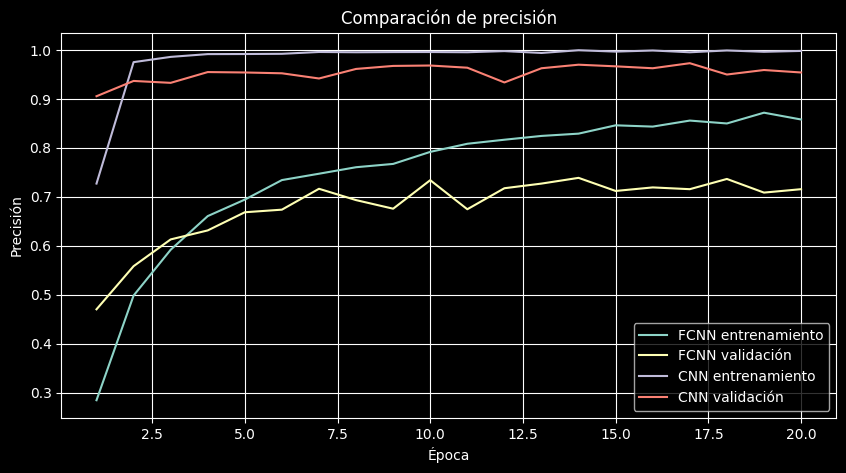

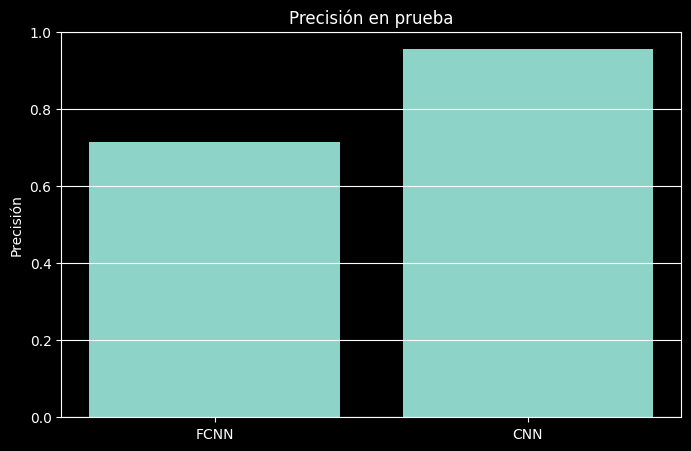

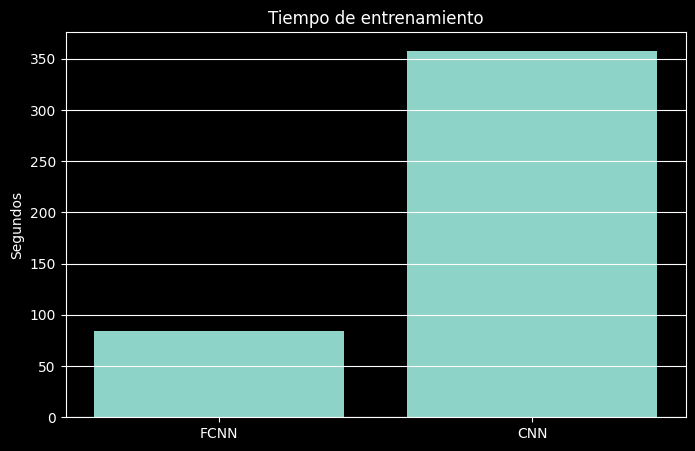

RESPUESTA 3
Observación de las curvas de aprendizaje
La mejor precisión de validación de FCNN fue 0.7387.
La mejor precisión de validación de CNN fue 0.9730.
En general, si la curva de entrenamiento sube mucho más que la de validación, existe sobreajuste.
Aquí la CNN aprende mejor los patrones espaciales de la imagen, por eso logra mayor precisión.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

faltantes = []
for nombre in ["fcnn_res", "cnn_res", "model_fcnn", "model_cnn", "test_loader", "loss_function"]:
    if nombre not in globals():
        faltantes.append(nombre)

if len(faltantes) > 0:
    print("Faltan variables para la reflexión:")
    print(faltantes)
    print("Ejecuta primero las celdas de entrenamiento y prueba.")
else:
    if "fcnn_test_loss" not in globals() or "fcnn_test_acc" not in globals():
        fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

    if "cnn_test_loss" not in globals() or "cnn_test_acc" not in globals():
        cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

    tiempo_fcnn_segundos = 84
    tiempo_cnn_segundos = 358

    mejor_modelo = "CNN" if cnn_test_acc > fcnn_test_acc else "FCNN"
    modelo_mas_rapido = "FCNN" if tiempo_fcnn_segundos < tiempo_cnn_segundos else "CNN"

    print("RESPUESTA 1")
    print("Qué modelo clasifica mejor las imágenes ASL")
    print(f"El mejor modelo es {mejor_modelo}.")
    print(f"FCNN  precisión en prueba: {fcnn_test_acc:.4f}")
    print(f"CNN   precisión en prueba: {cnn_test_acc:.4f}")
    print()

    print("RESPUESTA 2")
    print("Qué modelo fue más rápido al entrenar")
    print(f"El modelo más rápido fue {modelo_mas_rapido}.")
    print(f"Tiempo FCNN: {tiempo_fcnn_segundos} segundos")
    print(f"Tiempo CNN: {tiempo_cnn_segundos} segundos")
    print()

    epocas_fcnn = range(1, len(fcnn_res["train_loss"]) + 1)
    epocas_cnn = range(1, len(cnn_res["train_loss"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epocas_fcnn, fcnn_res["train_loss"], label="FCNN entrenamiento")
    plt.plot(epocas_fcnn, fcnn_res["val_loss"], label="FCNN validación")
    plt.plot(epocas_cnn, cnn_res["train_loss"], label="CNN entrenamiento")
    plt.plot(epocas_cnn, cnn_res["val_loss"], label="CNN validación")
    plt.title("Comparación de pérdida")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epocas_fcnn, fcnn_res["train_acc"], label="FCNN entrenamiento")
    plt.plot(epocas_fcnn, fcnn_res["val_acc"], label="FCNN validación")
    plt.plot(epocas_cnn, cnn_res["train_acc"], label="CNN entrenamiento")
    plt.plot(epocas_cnn, cnn_res["val_acc"], label="CNN validación")
    plt.title("Comparación de precisión")
    plt.xlabel("Época")
    plt.ylabel("Precisión")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    nombres_modelos = ["FCNN", "CNN"]
    precisiones_prueba = [fcnn_test_acc, cnn_test_acc]
    plt.bar(nombres_modelos, precisiones_prueba)
    plt.title("Precisión en prueba")
    plt.ylabel("Precisión")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.show()

    plt.figure(figsize=(8, 5))
    tiempos = [tiempo_fcnn_segundos, tiempo_cnn_segundos]
    plt.bar(nombres_modelos, tiempos)
    plt.title("Tiempo de entrenamiento")
    plt.ylabel("Segundos")
    plt.grid(axis="y")
    plt.show()

    mejor_val_fcnn = max(fcnn_res["val_acc"])
    mejor_val_cnn = max(cnn_res["val_acc"])

    print("RESPUESTA 3")
    print("Observación de las curvas de aprendizaje")
    print(f"La mejor precisión de validación de FCNN fue {mejor_val_fcnn:.4f}.")
    print(f"La mejor precisión de validación de CNN fue {mejor_val_cnn:.4f}.")
    print("En general, si la curva de entrenamiento sube mucho más que la de validación, existe sobreajuste.")
    print("Aquí la CNN aprende mejor los patrones espaciales de la imagen, por eso logra mayor precisión.")

### Which model was _faster_ to train?

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

RESPUESTA 4
Cantidad de parámetros entrenables
FCNN: 676,888 parámetros
CNN:  403,799 parámetros



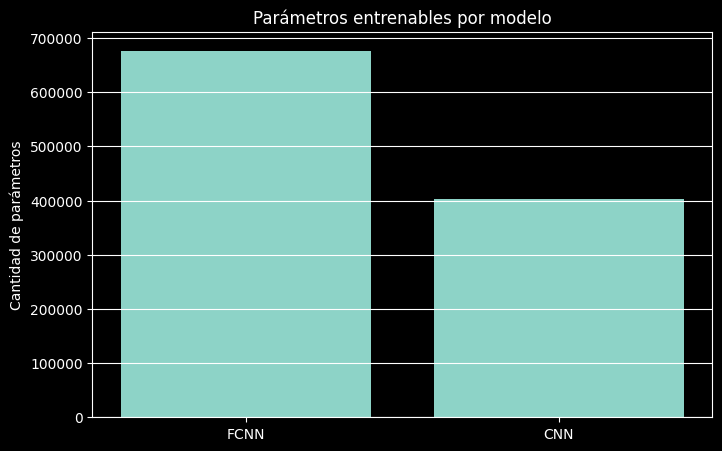

RESPUESTA 5
Comparación en términos de sobreajuste
Diferencia final entre precisión de entrenamiento y validación en FCNN: 0.1424
Diferencia final entre precisión de entrenamiento y validación en CNN: 0.0440
Diferencia final entre pérdida de validación y entrenamiento en FCNN: 0.6548
Diferencia final entre pérdida de validación y entrenamiento en CNN: 0.1859

La FCNN muestra más señales de sobreajuste que la CNN.
Esto suele pasar porque la CNN aprovecha mejor la estructura espacial de las imágenes.
Las capas convolucionales detectan bordes, formas y patrones locales, mientras que la FCNN trata todos los píxeles como si fueran independientes.

Sin embargo, esa mejora tuvo el costo de un entrenamiento más lento.
En resumen, la FCNN fue más rápida y simple, pero la CNN fue más adecuada para clasificar imágenes de lenguaje de señas porque entiende mejor la información visual.


In [21]:
def contar_parametros_entrenables(modelo):
    return sum(parametro.numel() for parametro in modelo.parameters() if parametro.requires_grad)

faltantes = []
for nombre in ["fcnn_res", "cnn_res", "model_fcnn", "model_cnn"]:
    if nombre not in globals():
        faltantes.append(nombre)

if len(faltantes) > 0:
    print("Faltan variables para completar la reflexión:")
    print(faltantes)
    print("Ejecuta primero las celdas anteriores.")
else:
    parametros_fcnn = contar_parametros_entrenables(model_fcnn)
    parametros_cnn = contar_parametros_entrenables(model_cnn)

    diferencia_fcnn = fcnn_res["train_acc"][-1] - fcnn_res["val_acc"][-1]
    diferencia_cnn = cnn_res["train_acc"][-1] - cnn_res["val_acc"][-1]

    perdida_fcnn = fcnn_res["val_loss"][-1] - fcnn_res["train_loss"][-1]
    perdida_cnn = cnn_res["val_loss"][-1] - cnn_res["train_loss"][-1]

    print("RESPUESTA 4")
    print("Cantidad de parámetros entrenables")
    print(f"FCNN: {parametros_fcnn:,} parámetros")
    print(f"CNN:  {parametros_cnn:,} parámetros")
    print()

    plt.figure(figsize=(8, 5))
    plt.bar(["FCNN", "CNN"], [parametros_fcnn, parametros_cnn])
    plt.title("Parámetros entrenables por modelo")
    plt.ylabel("Cantidad de parámetros")
    plt.grid(axis="y")
    plt.show()

    print("RESPUESTA 5")
    print("Comparación en términos de sobreajuste")
    print(f"Diferencia final entre precisión de entrenamiento y validación en FCNN: {diferencia_fcnn:.4f}")
    print(f"Diferencia final entre precisión de entrenamiento y validación en CNN: {diferencia_cnn:.4f}")
    print(f"Diferencia final entre pérdida de validación y entrenamiento en FCNN: {perdida_fcnn:.4f}")
    print(f"Diferencia final entre pérdida de validación y entrenamiento en CNN: {perdida_cnn:.4f}")
    print()

    if diferencia_fcnn > diferencia_cnn:
        print("La FCNN muestra más señales de sobreajuste que la CNN.")
    elif diferencia_cnn > diferencia_fcnn:
        print("La CNN muestra más señales de sobreajuste que la FCNN.")
    else:
        print("Ambos modelos muestran un nivel de sobreajuste parecido.")

    print("Esto suele pasar porque la CNN aprovecha mejor la estructura espacial de las imágenes.")
    print("Las capas convolucionales detectan bordes, formas y patrones locales, mientras que la FCNN trata todos los píxeles como si fueran independientes.")
    print()


    print("Sin embargo, esa mejora tuvo el costo de un entrenamiento más lento.")
    print("En resumen, la FCNN fue más rápida y simple, pero la CNN fue más adecuada para clasificar imágenes de lenguaje de señas porque entiende mejor la información visual.")

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

FCNN: 676,888 parámetros
CNN:  403,799 parámetros

### How do the models compare in terms of overfitting? Why do you think that is the case?

como respondi dentro del propio codigo La FCNN muestra más señales de sobreajuste que la CNN.
Esto suele pasar porque la CNN aprovecha mejor la estructura espacial de las imágenes.
Las capas convolucionales detectan bordes, formas y patrones locales, mientras que la FCNN trata todos los píxeles como si fueran independientes.


### Final conclusions and remarks

Conclusiones finales
La CNN fue la mejor opción para este problema porque logró mayor precisión en prueba.
Sin embargo, esa mejora tuvo el costo de un entrenamiento más lento.
En resumen, la FCNN fue más rápida y simple, pero la CNN fue más adecuada para clasificar imágenes de lenguaje de señas porque entiende mejor la información visual.